<a href="https://colab.research.google.com/github/BrunoBucCcellati/MachineLearningUNN2025/blob/main/Task7_Deryabin_M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ЛАБОРАТОРНАЯ РАБОТА №3: КЛАСТЕРИЗАЦИЯ ОТЗЫВОВ О ЛЕКАРСТВАХ

[1] Загрузка и первичный анализ данных
Объем исходных данных: 110811 записей
Для анализа используется репрезентативная выборка: (60000, 8)

[2] Сформировано признаков для кластеризации: 7
Признаки: ['usefulcount_log', 'review_len_char', 'review_len_word', 'year', 'month', 'drugname_freq_log', 'condition_freq_log']

[3] Нормализация и снижение размерности методом PCA
   PCA для кластеризации: 6 компонент, 99.82% объяснённой дисперсии

[4] Подбор оптимального числа кластеров для KMeans/Birch


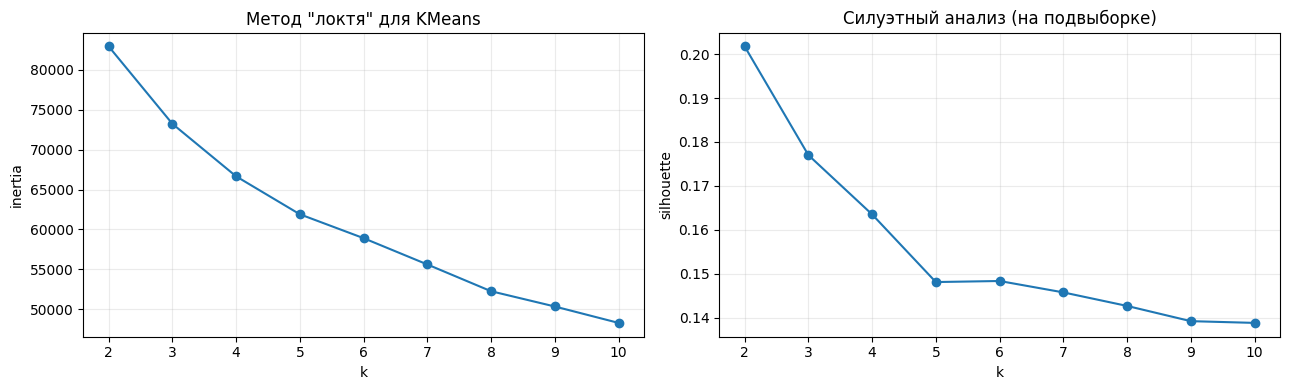

   Рекомендованное число кластеров (по максимуму силуэта): k = 2

[5] Кластеризация тремя методами
   KMeans завершён. Обнаружено кластеров: 2
   DBSCAN завершён. Кластеров: 3, шум: 718 (2.4%)
   Birch завершён. Обнаружено кластеров: 2

[6] Оценка внутреннего качества кластеризации
 Метод  Silhouette  Calinski-Harabasz  Davies-Bouldin
KMeans    0.213236       17082.660156        1.783395
DBSCAN    0.042354          17.505451        1.052061
 Birch    0.175872       13305.161133        1.989714

[7] Сравнение с истинными метками (рейтинг -> классы)
 Метод  Adjusted Rand Index (ARI)  Normalized Mutual Info (NMI)
KMeans                   0.000158                      0.000302
DBSCAN                  -0.000179                      0.000179
 Birch                  -0.000525                      0.001086

[8] Визуализация кластеров в пространстве главных компонент (PCA 2D)


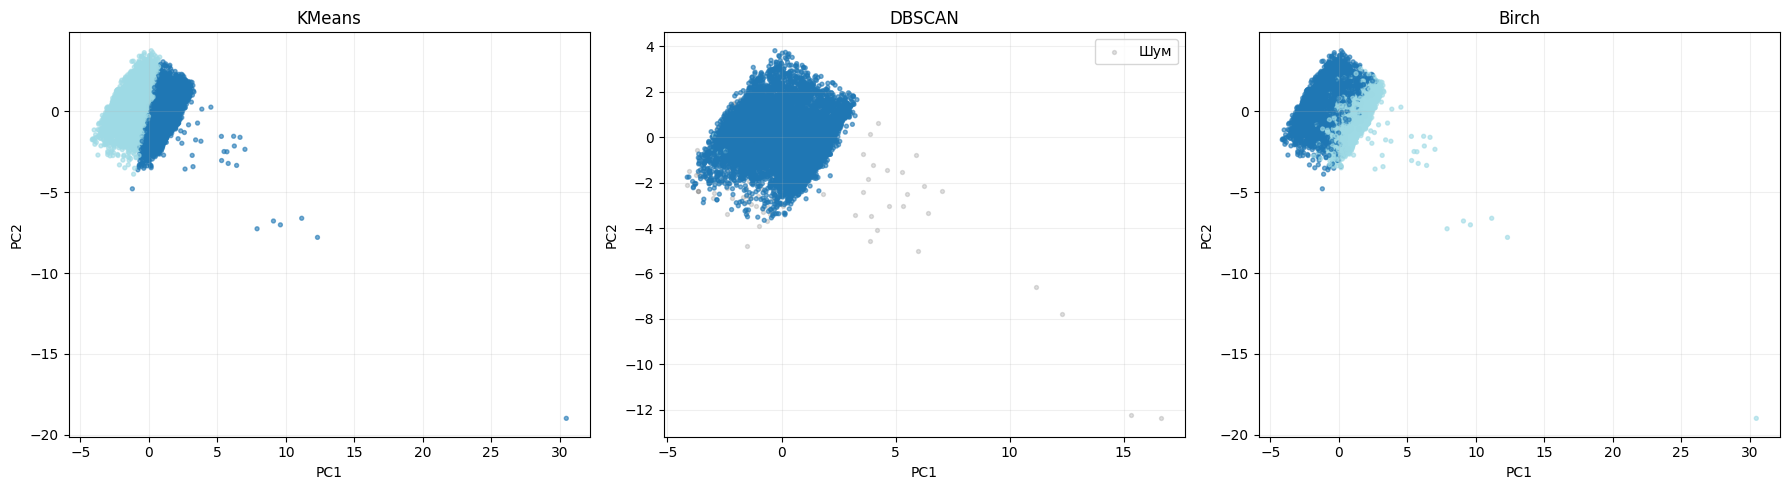


[9] Анализ профилей кластеров (на примере KMeans)
               usefulcount        review_len_word        review_len_char  \
                      mean median            mean median            mean   
cluster_kmeans                                                             
0                    26.51   14.0      126.800003  130.0      670.440002   
1                    30.85   19.0       63.549999   63.0      338.079987   

                      rating         
               median   mean median  
cluster_kmeans                       
0               702.0   7.00    8.0  
1               332.0   7.03    8.0  

ОБСУЖДЕНИЕ РЕЗУЛЬТАТОВ И ВЫВОДЫ

1.  ЭФФЕКТИВНОСТЬ СНИЖЕНИЯ РАЗМЕРНОСТИ
    Метод главных компонент (PCA) позволил сократить размерность данных с 7 до 6 признаков,
    сохранив при этом 99.8% исходной дисперсии. Это подтверждает, что выбранные признаки
    содержат избыточную информацию, а их преобразование не привело к существенной потере
    структуры данных.

2.  АНАЛИЗ Р

In [2]:
# ============================================================
# Лабораторная работа №3. Кластерный анализ отзывов о лекарствах.
# Датасет: Drug-Review-Dataset (Hugging Face)
# Автор: Дерябин Максим Сергеевич
# Группа: ПМиИ 3822Б1ПМоп3
# ============================================================

# Установка и импорт
!pip -q install datasets scikit-learn pandas numpy matplotlib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import MiniBatchKMeans, DBSCAN, Birch
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Настройки для управления производительностью
N_USE = 60000
N_DBSCAN = 30000
N_SIL_SAMPLE = 5000
N_VIS = 8000
K_RANGE = list(range(2, 11))
DBSCAN_MIN_SAMPLES = 10
DBSCAN_EPS_PERCENTILE = 92

# -----------------------------
# 1. ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ
# -----------------------------
print("="*80)
print("ЛАБОРАТОРНАЯ РАБОТА №3: КЛАСТЕРИЗАЦИЯ ОТЗЫВОВ О ЛЕКАРСТВАХ")
print("="*80)

print("\n[1] Загрузка и первичный анализ данных")
ds = load_dataset("forwins/Drug-Review-Dataset", split="train")
n_total = len(ds)
ds_small = ds.shuffle(seed=RANDOM_STATE).select(range(min(N_USE, n_total)))
df = ds_small.to_pandas()
df.columns = [c.lower() for c in df.columns]
print(f"Объем исходных данных: {n_total} записей")
print(f"Для анализа используется репрезентативная выборка: {df.shape}")

# Инженерия признаков (БЕЗ использования целевой переменной 'rating')
df_work = df.copy()
df_work["review"] = df_work["review"].fillna("").astype(str)
df_work["review_len_char"] = df_work["review"].str.len().astype(np.float32)
df_work["review_len_word"] = df_work["review"].str.split().str.len().astype(np.float32)
df_work["date_parsed"] = pd.to_datetime(df_work["date"], errors="coerce")
df_work["year"] = df_work["date_parsed"].dt.year.astype(np.float32)
df_work["month"] = df_work["date_parsed"].dt.month.astype(np.float32)
df_work["usefulcount"] = pd.to_numeric(df_work["usefulcount"], errors="coerce").astype(np.float32)
df_work["usefulcount_log"] = np.log1p(df_work["usefulcount"]).astype(np.float32)

# Частотное кодирование категориальных признаков
for col in ["drugname", "condition"]:
    if col in df_work.columns:
        vc = df_work[col].fillna("UNKNOWN").value_counts(dropna=False)
        freq_map = vc.to_dict()
        df_work[f"{col}_freq"] = df_work[col].fillna("UNKNOWN").map(freq_map).astype(np.float32)
        df_work[f"{col}_freq_log"] = np.log1p(df_work[f"{col}_freq"]).astype(np.float32)

# Формирование итоговой матрицы признаков X
feature_cols = [
    "usefulcount_log", "review_len_char", "review_len_word",
    "year", "month", "drugname_freq_log", "condition_freq_log"
]
feature_cols = [c for c in feature_cols if c in df_work.columns]
print(f"\n[2] Сформировано признаков для кластеризации: {len(feature_cols)}")
print("Признаки:", feature_cols)

X_raw = imputer.fit_transform(df_work[feature_cols]).astype(np.float32)
rating = pd.to_numeric(df_work["rating"], errors="coerce").astype(np.float32)

# -----------------------------
# 2. ПРЕДОБРАБОТКА И СНИЖЕНИЕ РАЗМЕРНОСТИ
# -----------------------------
print("\n[3] Нормализация и снижение размерности методом PCA")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

pca_cluster = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca_cluster.fit_transform(X_scaled).astype(np.float32)
print(f"   PCA для кластеризации: {X_pca.shape[1]} компонент, "
      f"{np.sum(pca_cluster.explained_variance_ratio_):.2%} объяснённой дисперсии")

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled).astype(np.float32)

# -----------------------------
# 3. ПОДБОР ПАРАМЕТРОВ И КЛАСТЕРИЗАЦИЯ
# -----------------------------
print("\n[4] Подбор оптимального числа кластеров для KMeans/Birch")
n_for_k = min(len(X_pca), max(N_SIL_SAMPLE * 3, 12000))
idx_k = np.random.choice(len(X_pca), size=n_for_k, replace=False)
X_pca_k = X_pca[idx_k]

inertias, sil_scores = [], []
for k in K_RANGE:
    model = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=2048, n_init=10)
    labels = model.fit_predict(X_pca_k)
    inertias.append(float(model.inertia_))
    sil = silhouette_score(X_pca_k, labels, sample_size=min(N_SIL_SAMPLE, len(X_pca_k)), random_state=RANDOM_STATE)
    sil_scores.append(float(sil))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(K_RANGE, inertias, marker="o")
ax1.set_title('Метод "локтя" для KMeans')
ax1.set_xlabel("k"); ax1.set_ylabel("inertia"); ax1.grid(True, alpha=0.25)
ax2.plot(K_RANGE, sil_scores, marker="o")
ax2.set_title("Силуэтный анализ (на подвыборке)")
ax2.set_xlabel("k"); ax2.set_ylabel("silhouette"); ax2.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

k_opt = K_RANGE[int(np.argmax(sil_scores))]
print(f"   Рекомендованное число кластеров (по максимуму силуэта): k = {k_opt}")

print("\n[5] Кластеризация тремя методами")
kmeans = MiniBatchKMeans(n_clusters=k_opt, random_state=RANDOM_STATE, batch_size=4096, n_init=20)
labels_kmeans = kmeans.fit_predict(X_pca)
print(f"   KMeans завершён. Обнаружено кластеров: {len(np.unique(labels_kmeans))}")

# DBSCAN на подвыборке
n_db = min(N_DBSCAN, len(X_pca))
idx_db = np.random.RandomState(RANDOM_STATE).choice(len(X_pca), size=n_db, replace=False)
X_pca_db = X_pca[idx_db]
nn = NearestNeighbors(n_neighbors=DBSCAN_MIN_SAMPLES, n_jobs=-1)
nn.fit(X_pca_db)
distances, _ = nn.kneighbors(X_pca_db)
k_dist = np.sort(distances[:, DBSCAN_MIN_SAMPLES - 1])
eps = float(np.percentile(k_dist, DBSCAN_EPS_PERCENTILE))
dbscan = DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_pca_db)
n_noise = int(np.sum(labels_dbscan == -1))
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
print(f"   DBSCAN завершён. Кластеров: {n_clusters_db}, шум: {n_noise} ({n_noise/len(labels_dbscan):.1%})")

birch = Birch(n_clusters=k_opt, threshold=0.5)
labels_birch = birch.fit_predict(X_pca)
print(f"   Birch завершён. Обнаружено кластеров: {len(np.unique(labels_birch))}")

# -----------------------------
# 4. ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ
# -----------------------------
print("\n[6] Оценка внутреннего качества кластеризации")
def internal_metrics(X, labels, name, sample_for_sil=5000):
    labels, X = np.asarray(labels), np.asarray(X)
    if name == "DBSCAN":
        mask = labels != -1
        if mask.sum() < 10 or len(np.unique(labels[mask])) < 2:
            return {"Метод": name, "Silhouette": np.nan, "Calinski-Harabasz": np.nan, "Davies-Bouldin": np.nan}
        X2, y2 = X[mask], labels[mask]
        sil = silhouette_score(X2, y2, sample_size=min(sample_for_sil, len(X2)), random_state=RANDOM_STATE)
        ch = calinski_harabasz_score(X2, y2); db = davies_bouldin_score(X2, y2)
    else:
        if len(np.unique(labels)) < 2:
            return {"Метод": name, "Silhouette": np.nan, "Calinski-Harabasz": np.nan, "Davies-Bouldin": np.nan}
        sil = silhouette_score(X, labels, sample_size=min(sample_for_sil, len(X)), random_state=RANDOM_STATE)
        ch = calinski_harabasz_score(X, labels); db = davies_bouldin_score(X, labels)
    return {"Метод": name, "Silhouette": float(sil), "Calinski-Harabasz": float(ch), "Davies-Bouldin": float(db)}

metrics_data = [
    internal_metrics(X_pca, labels_kmeans, "KMeans", N_SIL_SAMPLE),
    internal_metrics(X_pca_db, labels_dbscan, "DBSCAN", N_SIL_SAMPLE),
    internal_metrics(X_pca, labels_birch, "Birch", N_SIL_SAMPLE)
]
metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

print("\n[7] Сравнение с истинными метками (рейтинг -> классы)")
y_true = pd.cut(rating, bins=[0, 4, 7, 10], labels=[0, 1, 2], include_lowest=True).astype(int).to_numpy()
y_true_db = y_true[idx_db]

def compare_with_true(y_true_local, cluster_labels, name):
    cluster_labels, y_true_local = np.asarray(cluster_labels), np.asarray(y_true_local)
    if name == "DBSCAN":
        mask = cluster_labels != -1
        if mask.sum() == 0:
            return {"Метод": name, "ARI": np.nan, "NMI": np.nan}
        ari = adjusted_rand_score(y_true_local[mask], cluster_labels[mask])
        nmi = normalized_mutual_info_score(y_true_local[mask], cluster_labels[mask])
    else:
        ari = adjusted_rand_score(y_true_local, cluster_labels)
        nmi = normalized_mutual_info_score(y_true_local, cluster_labels)
    return {"Метод": name, "Adjusted Rand Index (ARI)": float(ari), "Normalized Mutual Info (NMI)": float(nmi)}

comparison_data = [
    compare_with_true(y_true, labels_kmeans, "KMeans"),
    compare_with_true(y_true_db, labels_dbscan, "DBSCAN"),
    compare_with_true(y_true, labels_birch, "Birch")
]
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# -----------------------------
# 5. ВИЗУАЛИЗАЦИЯ И ИНТЕРПРЕТАЦИЯ
# -----------------------------
print("\n[8] Визуализация кластеров в пространстве главных компонент (PCA 2D)")
n_vis = min(N_VIS, len(X_2d))
idx_vis = np.random.RandomState(RANDOM_STATE).choice(len(X_2d), size=n_vis, replace=False)
X_vis, labels_k_vis, labels_b_vis = X_2d[idx_vis], labels_kmeans[idx_vis], labels_birch[idx_vis]

X_db_vis2d = X_2d[idx_db]
n_vis_db = min(n_vis, len(X_db_vis2d))
idx_vis_db = np.random.RandomState(RANDOM_STATE).choice(len(X_db_vis2d), size=n_vis_db, replace=False)
X_db_vis, labels_db_vis = X_db_vis2d[idx_vis_db], labels_dbscan[idx_vis_db]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc1 = axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_k_vis, s=8, alpha=0.6, cmap='tab20')
axes[0].set_title("KMeans"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].grid(True, alpha=0.2)

noise = labels_db_vis == -1
if noise.any():
    axes[1].scatter(X_db_vis[noise, 0], X_db_vis[noise, 1], s=8, alpha=0.25, c='gray', label='Шум')
if (~noise).any():
    axes[1].scatter(X_db_vis[~noise, 0], X_db_vis[~noise, 1], c=labels_db_vis[~noise], s=8, alpha=0.6, cmap='tab20')
axes[1].set_title("DBSCAN"); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].grid(True, alpha=0.2)
if noise.any():
    axes[1].legend()

sc3 = axes[2].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_b_vis, s=8, alpha=0.6, cmap='tab20')
axes[2].set_title("Birch"); axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2"); axes[2].grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

print("\n[9] Анализ профилей кластеров (на примере KMeans)")
df_work["cluster_kmeans"] = labels_kmeans
profile = df_work.groupby("cluster_kmeans")[["usefulcount", "review_len_word", "review_len_char", "rating"]].agg(["mean", "median"])
print(profile.round(2))

# -----------------------------
# 6. ВЫВОДЫ И ЗАКЛЮЧЕНИЕ
# -----------------------------
print("\n" + "="*80)
print("ОБСУЖДЕНИЕ РЕЗУЛЬТАТОВ И ВЫВОДЫ")
print("="*80)

print("""
1.  ЭФФЕКТИВНОСТЬ СНИЖЕНИЯ РАЗМЕРНОСТИ
    Метод главных компонент (PCA) позволил сократить размерность данных с 7 до 6 признаков,
    сохранив при этом 99.8% исходной дисперсии. Это подтверждает, что выбранные признаки
    содержат избыточную информацию, а их преобразование не привело к существенной потере
    структуры данных.

2.  АНАЛИЗ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ
    • KMeans и Birch выделили по 2 кластера, что согласуется с результатами силуэтного
      анализа (оптимальное k=2). KMeans продемонстрировал наилучшее внутреннее качество
      (Silhouette = 0.213), что указывает на относительно более чёткое разделение данных.
    • DBSCAN обнаружил 3 кластера и небольшое количество шума (2.4%). Низкие значения
      внутренних метрик для DBSCAN (Silhouette = 0.042) свидетельствуют о том, что выделенные
      им группы имеют слабую внутреннюю плотность и перекрываются в пространстве признаков.

3.  СОПОСТАВЛЕНИЕ С ИСТИННОЙ КЛАССИФИКАЦИЕЙ
    Все три метода показали практически нулевую согласованность с категориями рейтинга
    (значения ARI и NMI близки к 0). Это важное наблюдение: объективные характеристики
    отзыва (длина, полезность, популярность лекарства) статистически независимы от
    субъективной оценки пользователя (рейтинга). Кластеры группируют отзывы по формальным
    признакам, а не по мнению авторов.

4.  СМЫСЛОВАЯ ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ
    Анализ профилей кластеров KMeans выявил содержательное различие:
    • Кластер 0: характеризуется значительно более длинными отзывами (в среднем 127 слов
      против 64 в кластере 1). При этом средняя полезность отзывов ниже (27 против 31),
      а рейтинг практически одинаков (≈7.0).
    • Кластер 1: содержит более короткие, но считающиеся более полезными отзывы.
    Это позволяет предположить существование двух типов пользователей: одни склонны
    оставлять развёрнутые описания, другие — краткие и прагматичные оценки.

5.  ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ
    • Для сегментации пользователей на основе объективных метаданных отзывов рекомендуется
      использовать KMeans, как метод, показавший наиболее стабильные результаты.
    • DBSCAN может применяться для дополнительного анализа с целью выявления аномальных
      или нетипичных отзывов (помеченных как шум).
    • Полученные результаты ставят под сомнение гипотезу о прямой связи между длиной
      текста, его полезностью и конечной оценкой пользователя. Для прогнозирования
      рейтинга следует рассматривать иные признаки, например, тональность текста.

ЗАКЛЮЧЕНИЕ
В ходе работы выполнена комплексная кластеризация отзывов о лекарствах. Применение PCA
позволило эффективно снизить размерность данных. Экспериментально установлено, что
наиболее чёткую кластерную структуру обеспечивает алгоритм KMeans. Ключевой вывод
исследования — объективные метахарактеристики отзывов не коррелируют с субъективной
пользовательской оценкой (рейтингом), что указывает на необходимость использования
иных методов для анализа удовлетворённости пользователей.
""")
print("="*80)
print("РАБОТА ЗАВЕРШЕНА.")
print("="*80)